### 1. Definirea problemei: Predictia pretului autoturismelor

* **Context si relevanta:**
Piata auto second-hand este extrem de dinamica. Un model de Machine Learning poate ajuta la stabilirea unui pret corect atat pentru vanzator, cat si pentru cumparator.

* **Obiective:**
Realizarea unui model de invatare supravegheata capabil sa prezica pretul de vanzare (selling_price) al autoturismelor second-hand.

* **Tipul problemei**: Sarcina este una de **regresie**, deoarece variabila tinta este continua si numerica.

* **Setul de date**: Modelele utilizeaza atribute tehnice precum **anul fabricatiei**, **kilometrajul**, **puterea motorului** si **tipul combustibiluli**.

* **Utilitatea**: Proiectul ofera o solutie obiectiva pentru stabilirea preturilor, eliminand erorile umane si oferind transparenta in tranzactiile auto.



In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
import shap
import joblib


In [14]:
df = pd.read_csv('../data/car_details.csv')
print(f"Dimensiune: {df.shape}")
df.info()
display(df.head())


Dimensiune: (8128, 13)
<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [15]:
cols = ['mileage', 'engine', 'max_power']
for col in cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.split(' ').str[0], errors='coerce')

print(df[['mileage', 'engine', 'max_power']].dtypes)

mileage      float64
engine       float64
max_power    float64
dtype: object


In [16]:
display(df.describe().T)

print("Skew:")
print(df.skew(numeric_only=True))

print("\nKurt:")
print(df.kurt(numeric_only=True))

,count,mean,std,min,25%,50%,75%,max
year,8128.0,2013.804011,4.044249,1983.0,2011.00,2015.0,2017.00,2020.0
selling_price,8128.0,638271.807702,806253.403508,29999.0,254999.00,450000.0,675000.00,10000000.0
km_driven,8128.0,69819.510827,56550.554958,1.0,35000.00,60000.0,98000.00,2360457.0
mileage,7907.0,19.418783,4.037145,0.0,16.78,19.3,22.32,42.0
engine,7907.0,1458.625016,503.916303,624.0,1197.00,1248.0,1582.00,3604.0
max_power,7912.0,91.517919,35.822499,0.0,68.05,82.0,102.00,400.0
seats,7907.0,5.416719,0.959588,2.0,5.00,5.0,5.00,14.0


Skew:
year             -1.072293
selling_price     4.193533
km_driven        11.170910
mileage          -0.142667
engine            1.135269
max_power         1.621261
seats             1.969914
dtype: float64

Kurt:
year               1.707013
selling_price     21.081289
km_driven        384.097414
mileage            0.569820
engine             0.732507
max_power          3.784481
seats              3.799509
dtype: float64


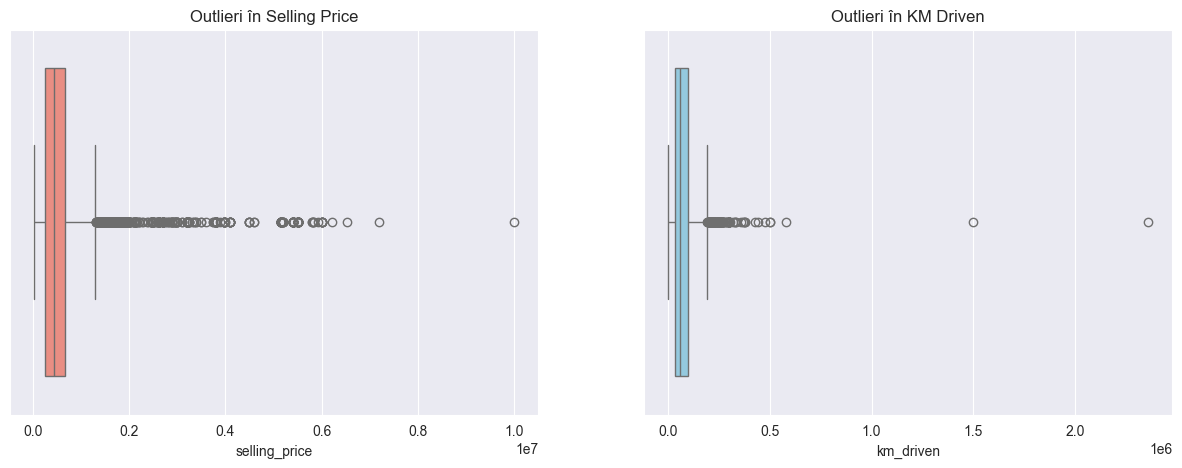

In [17]:
fig,axes = plt.subplots(1,2,figsize=(15,5))

sns.boxplot(ax=axes[0], x=df['selling_price'], color='salmon')
axes[0].set_title('Outlieri în Selling Price')

sns.boxplot(ax=axes[1], x=df['km_driven'], color='skyblue')
axes[1].set_title('Outlieri în KM Driven')

plt.show()

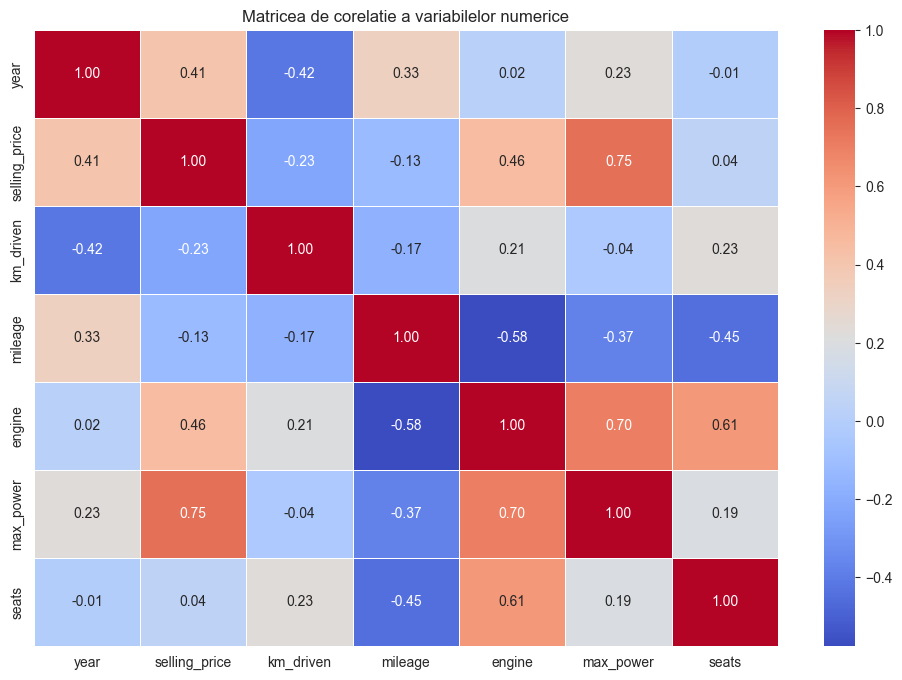

In [18]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matricea de corelatie a variabilelor numerice')
plt.show()

In [19]:
df = df[df['km_driven'] < 1000000]
if 'torque' in df.columns:
    df.drop(columns=['torque'], inplace=True)

print(f"Dimensiune dataset după curatarea anomaliilor: {df.shape}")

Dimensiune dataset după curatarea anomaliilor: (8126, 12)


In [20]:
df_final = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission', 'owner'], drop_first=True)
df_final.drop(columns=['name'], inplace=True)
display(df_final.head())

,year,selling_price,km_driven,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014,450000,145500,23.40,1248.0,74.00,5.0,True,False,False,True,False,True,False,False,False,False
1,2014,370000,120000,21.14,1498.0,103.52,5.0,True,False,False,True,False,True,False,True,False,False
2,2006,158000,140000,17.70,1497.0,78.00,5.0,False,False,True,True,False,True,False,False,False,True
3,2010,225000,127000,23.00,1396.0,90.00,5.0,True,False,False,True,False,True,False,False,False,False
4,2007,130000,120000,16.10,1298.0,88.20,5.0,False,False,True,True,False,True,False,False,False,False


In [21]:
print("Valori lipsa:\n", df_final.isnull().sum())
df_final.dropna(inplace=True)

print(f"Randuri ramase: {df_final.shape[0]}")
print(df_final.isnull().sum())

Valori lipsa:
 year                              0
selling_price                     0
km_driven                         0
mileage                         221
engine                          221
max_power                       216
seats                           221
fuel_Diesel                       0
fuel_LPG                          0
fuel_Petrol                       0
seller_type_Individual            0
seller_type_Trustmark Dealer      0
transmission_Manual               0
owner_Fourth & Above Owner        0
owner_Second Owner                0
owner_Test Drive Car              0
owner_Third Owner                 0
dtype: int64
Randuri ramase: 7904
year                            0
selling_price                   0
km_driven                       0
mileage                         0
engine                          0
max_power                       0
seats                           0
fuel_Diesel                     0
fuel_LPG                        0
fuel_Petrol                     0

In [22]:
X = df_final.drop('selling_price', axis=1)
y = df_final['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Date antrenare: {X_train.shape[0]} randuri")
print(f"Date testare: {X_test.shape[0]} randuri")

Date antrenare: 5928 randuri
Date testare: 1976 randuri


### 2. Analiza exploratorie a datelor (EDA)
* **Analiza statistica**: Calculul indicatorilor de **skewness** si **kurtosis** a scos in evidenta o asimetrie pozitiva pronuntata in cazul pretului si kilometrajului.
* **Tratarea anomaliilor**: Am identificat **outlieri extremi** (masini cu peste 1.000.000 km) si am decis eliminarea lor pentru a preveni influentarea negativa a pantei de regresie.
* **Relatii intre variabile**: Matricea de corelatie a confirmat ca **max_power** este cel mai puternic predictor pozitiv, in timp ce corelatia negativa a kilometrajului confirma deprecierea valorii odata cu uzura.

In [23]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "Gaussian Process": GaussianProcessRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(silent=True, random_state=42),
    "EBM": ExplainableBoostingRegressor()
}

In [24]:
results = []

for name,model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


In [25]:
df_results = pd.DataFrame(results).sort_values(by="R2", ascending=False)
display(df_results)

,Model,MSE,MAE,RMSE,R2
6,XGBoost,1.985575e+10,66878.664062,140910.436689,0.969938
7,CatBoost,2.274197e+10,71446.639265,150804.404797,0.965569
2,Random Forest,2.375468e+10,69702.197024,154125.534215,0.964035
8,EBM,3.262465e+10,78448.049598,180622.940290,0.950606
1,Decision Tree,4.299357e+10,82731.782865,207348.919883,0.934908
4,KNN,1.652549e+11,172689.420040,406515.560109,0.749803
0,Linear Regression,2.107150e+11,272827.074457,459037.058604,0.680977
5,Gaussian Process,3.441159e+11,305839.592407,586613.938977,0.479007
3,SVR,6.968524e+11,377317.371434,834776.835767,-0.055037


### 3. Antrenarea si compararea modelelor de baza:
* **Modelele cu acuratete ridicata:** Algoritmii XGBoost, CatBoost si Random Forest au demonstrat cele mai bune peformante, cu un scor $R^2$ de peste 0.96. Acest lucru confirma faptul ca relatia dintre caracteristicile tehnice ale masinilor si pret este una non-liniara si complexa.
* **Modele ineficiente:**
SVR a obtinut un scor negativ, indicad faptul ca modelul este mai slab decat o simpla medie a preturilor. Aceasta observatie subliniaza necesitatea aplicarii tehnicilor de scalare pentru algoritmii bazati pe distante.

### Metricile de testare
Performanta modelelor de predictie a pretului a fost cuantificata prin urmatoarele erori statistice:
* **MAE (Mean Absolute Error)**: Reprezinta media diferentelor absolute dintre pretul real si cel prezis. Spune, in medie, cu cati bani a ratat modelul pretul real.
* **MSE (Mean Squared Error)**: Calculeaza media patratelor erorilor. Prin ridicarea la patrat, aceasta metrica penalizeaza mult mai tare erorile mari.
* **RMSE (Root Mean Squared Error)**: Este radacina patrata a MSE si readuce eroarea la unitatea de masura originala (pretul masinii).
* **R2 (R-squared)**: Coeficientul de determinare indica cat de mult din variatia pretului este explicata de modelul nostru.


**Concluzie:** Pentru etapa de optimizare a hiperparametrilor, ne vom concentra pe primele 5 modele din clasament:
1. **XGBoost**
2. **CatBoost**
3. **Random Forest**
4. **EBM**
5. **Decision Tree**

In [30]:
xgb = XGBRegressor(random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid_xgb, cv=3, scoring='r2', n_jobs=-1, verbose=1)

grid_xgb.fit(X_train, y_train)

print(f"Cel mai bun scor R2: {grid_xgb.best_score_:.4f}")
print(f"Parametri optimi: {grid_xgb.best_params_}")

best_xgb = grid_xgb.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)

r2_final = r2_score(y_test, y_pred_tuned)
print(f"R2 Final (după tuning) pe setul de test: {r2_final:.4f}")

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Cel mai bun scor R2: 0.9626
Parametri optimi: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
R2 Final (după tuning) pe setul de test: 0.9744


In [32]:
cat = CatBoostRegressor(silent=True, random_state=42)

param_grid_cat = {
    'iterations':[500,1000],
    'depth':[6,8],
    'learning_rate':[0.03, 0.1]
}

grid_cat = GridSearchCV(estimator=cat, param_grid=param_grid_cat,
                        cv=3, scoring='r2', n_jobs=-1)

grid_cat.fit(X_train, y_train)

best_cat = grid_cat.best_estimator_
r2_cat_test = r2_score(y_test, best_cat.predict(X_test))

print(f"Scor R2 CatBoost (după tuning): {r2_cat_test:.4f}")
print(f"Parametri optimi: {grid_cat.best_params_}")

Scor R2 CatBoost (după tuning): 0.9698
Parametri optimi: {'depth': 6, 'iterations': 1000, 'learning_rate': 0.1}


In [38]:
rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 12, 15],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt']
}

grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf,
                       cv=3, scoring='r2', n_jobs=-1, verbose=1)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
rf_train_r2 = r2_score(y_train, best_rf.predict(X_train))
rf_test_r2 = r2_score(y_test, best_rf.predict(X_test))

print(f"Random Forest - R2 Antrenare: {rf_train_r2:.4f}")
print(f"Random Forest - R2 Test: {rf_test_r2:.4f}")
print(f"Parametri optimi: {grid_rf.best_params_}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Random Forest - R2 Antrenare: 0.9883
Random Forest - R2 Test: 0.9652
Parametri optimi: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}


In [44]:
ebm = ExplainableBoostingRegressor(random_state=42)

param_grid_ebm = {
    'learning_rate': [0.02],
    'interactions': [2, 3],
    'min_samples_leaf': [10]
}
grid_ebm = GridSearchCV(estimator=ebm, param_grid=param_grid_ebm,
                        cv=3, scoring='r2', n_jobs=1, verbose=1)

grid_ebm.fit(X_train, y_train)
best_ebm = grid_ebm.best_estimator_

ebm_train_r2 = r2_score(y_train, best_ebm.predict(X_train))
ebm_test_r2 = r2_score(y_test, best_ebm.predict(X_test))

print(f"EBM Tunat - R2 Antrenare: {ebm_train_r2:.4f}")
print(f"EBM Tunat - R2 Test: {ebm_test_r2:.4f}")
print(f"Parametri optimi: {grid_ebm.best_params_}")

Fitting 3 folds for each of 2 candidates, totalling 6 fits
EBM Tunat - R2 Antrenare: 0.9776
EBM Tunat - R2 Test: 0.9524
Parametri optimi: {'interactions': 3, 'learning_rate': 0.02, 'min_samples_leaf': 10}


In [47]:
dt = DecisionTreeRegressor(random_state=42)

param_grid_dt = {
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [5, 10],
    'min_samples_split': [20,40]
}

grid_dt = GridSearchCV(dt, param_grid_dt, cv=3, scoring='r2', n_jobs=-1)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
dt_train_r2 = r2_score(y_train, best_dt.predict(X_train))
dt_test_r2 = r2_score(y_test, best_dt.predict(X_test))

print(f"Decision Tree - R2 Antrenare: {dt_train_r2:.4f}")
print(f"Decision Tree - R2 Test: {dt_test_r2:.4f}")
print(f"Parametri optimi: {grid_dt.best_params_}")

Decision Tree - R2 Antrenare: 0.9661
Decision Tree - R2 Test: 0.9304
Parametri optimi: {'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 20}


### 4. Ajustarea hiperparametrilor
* **Metoda de cautare**: Am selectat primele 5 modele si am aplicat **GridSearchCV** pentru a gasi configuratia optima.
* **Strategie**: Am vizat reglarea a diferiti parametrii, precum  **max_depth** si **learning_rate** pentru a mentine echilibrul intre capacitatea de memorare si cea de generalizare a algoritmului.
* **Rezultat**: Dupa tuning, **XGBoost** a ramas cel mai performant model, obtinand o reducere a erorilor medii pe setul de testare.

In [ ]:
def plot_learning_curves(estimator, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=3, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='red', label='Antrenare')
    plt.plot(train_sizes, test_mean, 'o-', color='blue', label='Validare')

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="red")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="blue")


    plt.title(title)
    plt.xlabel("Numar de esantioane de antrenare")
    plt.ylabel("Scor R2")
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()



Could not connect to 127.0.0.1: 54816
Traceback (most recent call last):
  File "C:\PyCharm 2025.2.4\plugins\python-ce\helpers\pydev\_pydevd_bundle\pydevd_comm.py", line 443, in start_client
    s.connect((host, port))
ConnectionRefusedError: [WinError 10061] No connection could be made because the target machine actively refused it
Traceback (most recent call last):
  File "C:\PyCharm 2025.2.4\plugins\python-ce\helpers\jupyter_debug\pydev_jupyter_utils.py", line 84, in attach_to_debugger
    debugger.connect(pydev_localhost.get_localhost(), debugger_port)
  File "C:\PyCharm 2025.2.4\plugins\python-ce\helpers\pydev\pydevd.py", line 688, in connect
    s = start_client(host, port)
        ^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\PyCharm 2025.2.4\plugins\python-ce\helpers\pydev\_pydevd_bundle\pydevd_comm.py", line 443, in start_client
    s.connect((host, port))
ConnectionRefusedError: [WinError 10061] No connection could be made because the target machine actively refused it
Failed to connec

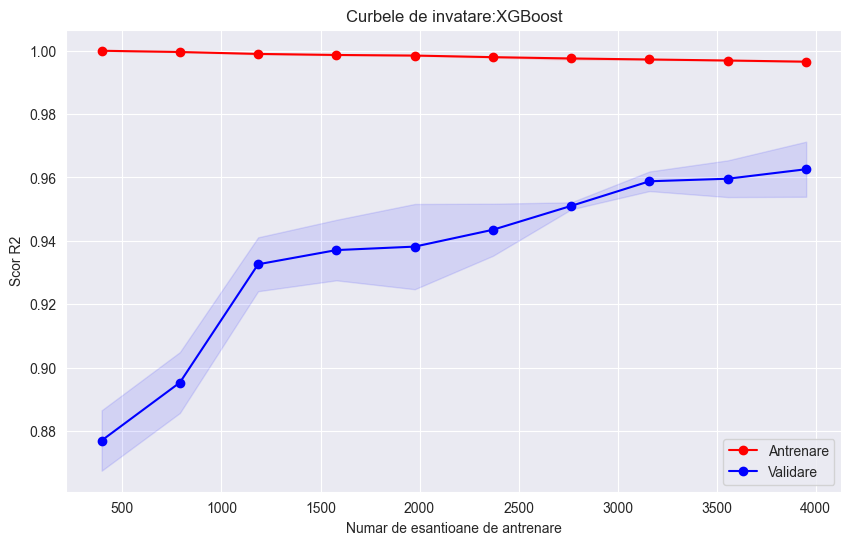

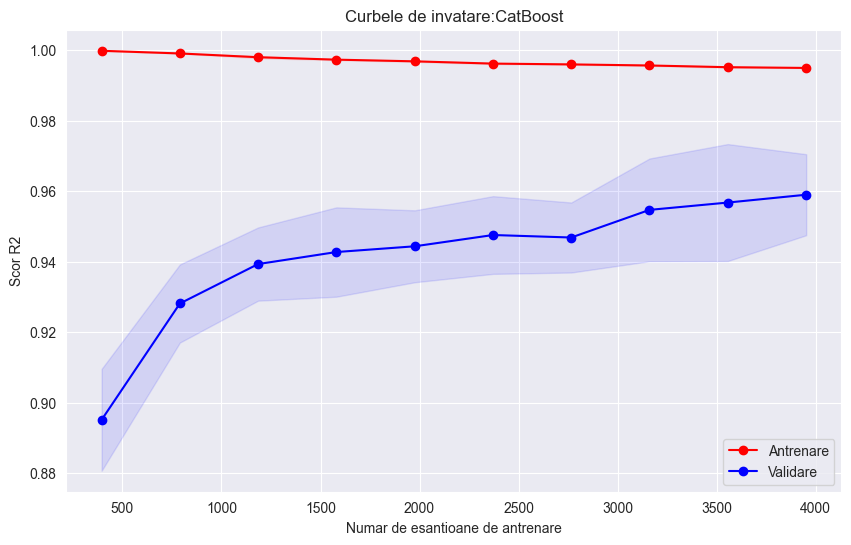

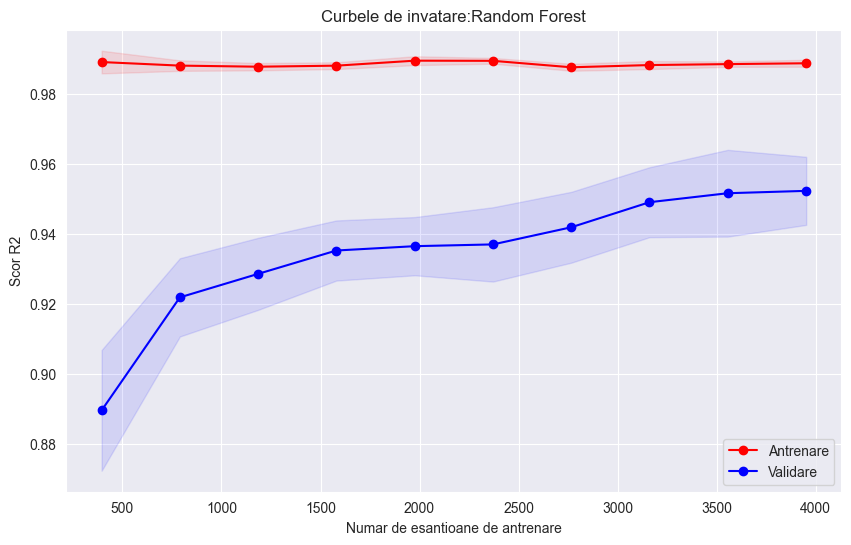

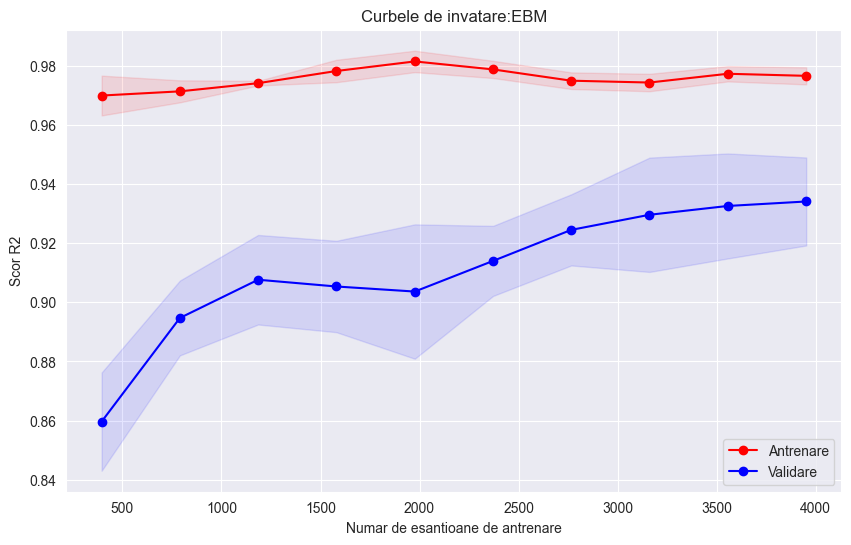

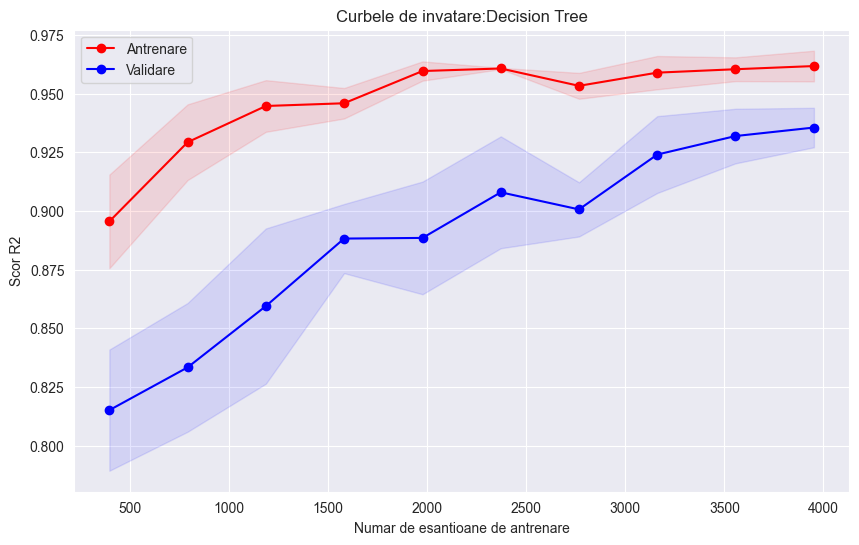

In [66]:
modele = [
    (best_xgb, "XGBoost"),
    (best_cat, "CatBoost"),
    (best_rf, "Random Forest"),
    (best_ebm, "EBM"),
    (best_dt, "Decision Tree")
]
for model, nume in modele:
    plot_learning_curves(model, X_train, y_train, f"Curbele de invatare:{nume}")
    file_name = f"lc_{nume.lower().replace(' ', '_')}.png"
    plt.savefig(f'{file_name}', bbox_inches='tight')
    plt.close()



### 5. Curbele de invatare
* **Diagnosticarea modelelor**: Am generat grafice de tip **learning curve** pentru a monitoriza evolutia scorului in functie de dimensiunea setului de date.
* **Concluzie**: Convergenta liniilor de antrenare si validare demonstreaza ca modelele nu sufera de **high variance** (overfitting) si ca au o stabilitate buna la intalnirea cu date noi.

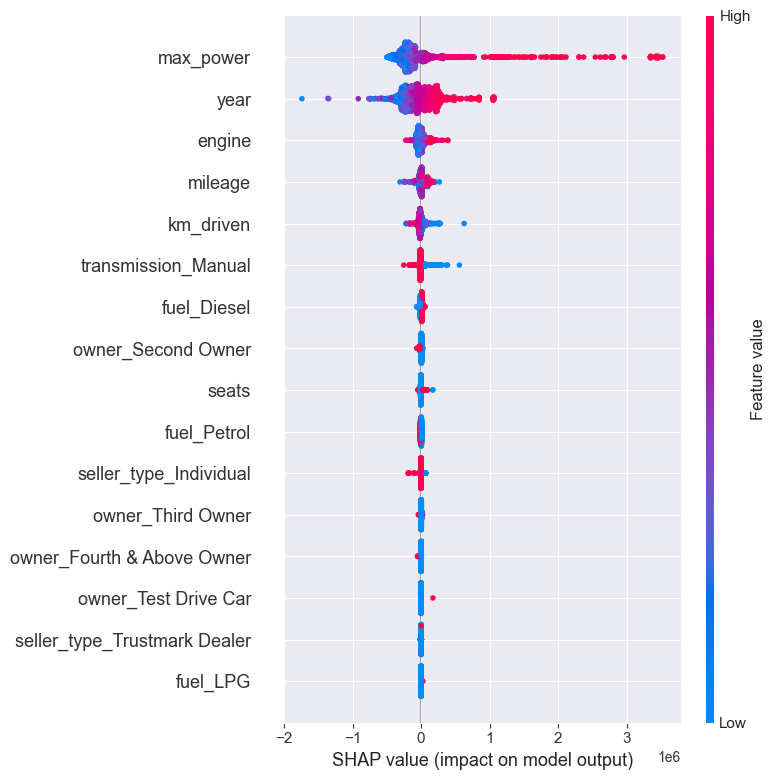

In [53]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot")

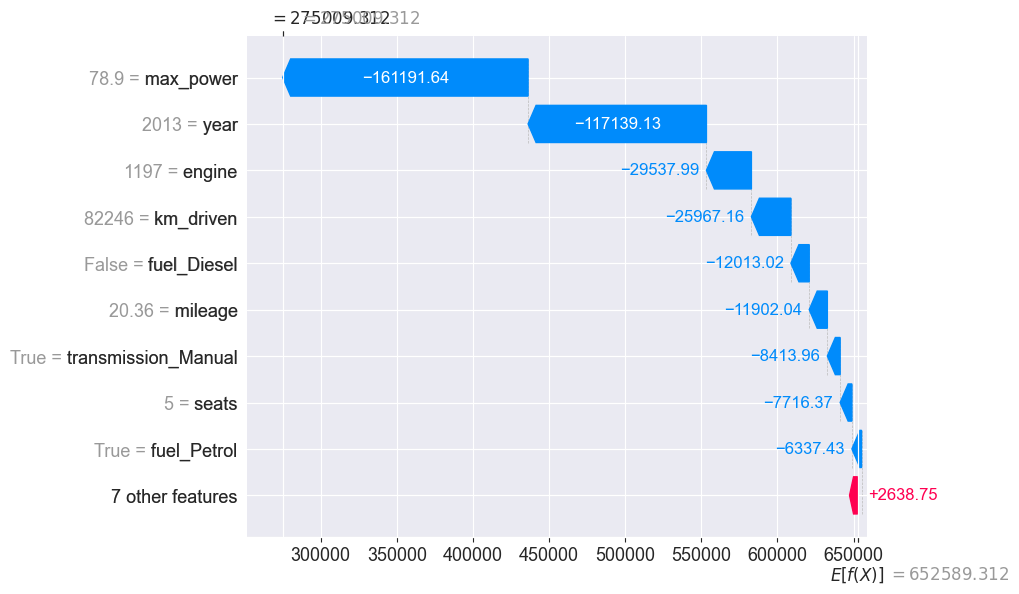

In [54]:
sample_idx = 0

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explainer(X_test)[sample_idx])



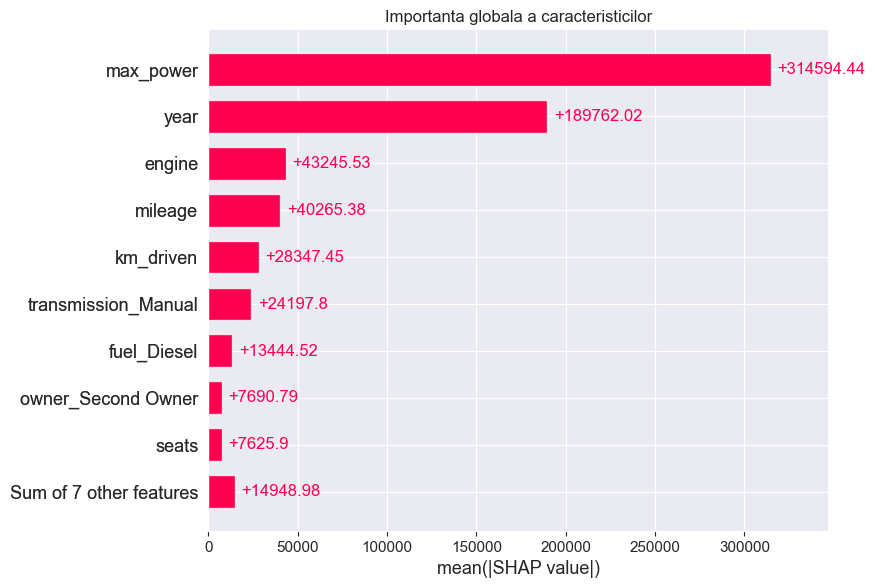

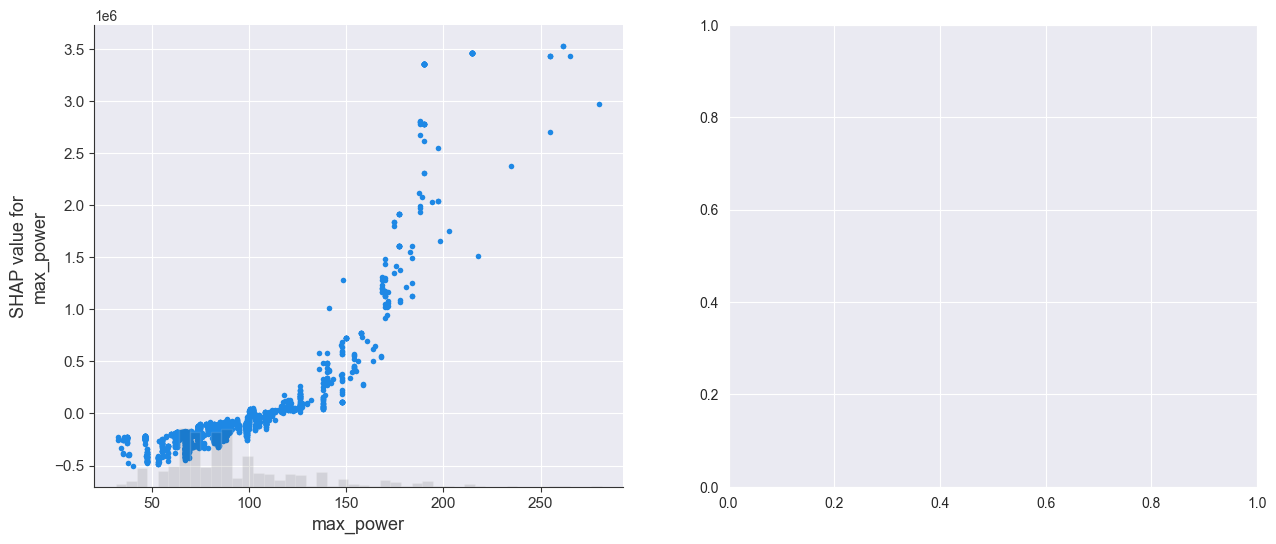

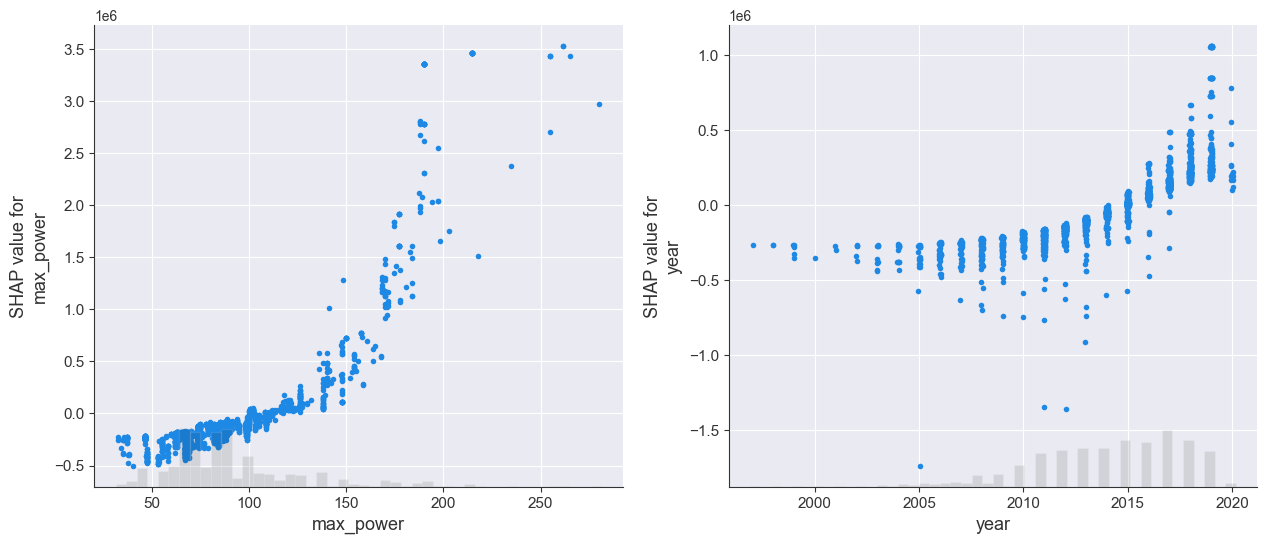

<Figure size 640x480 with 0 Axes>

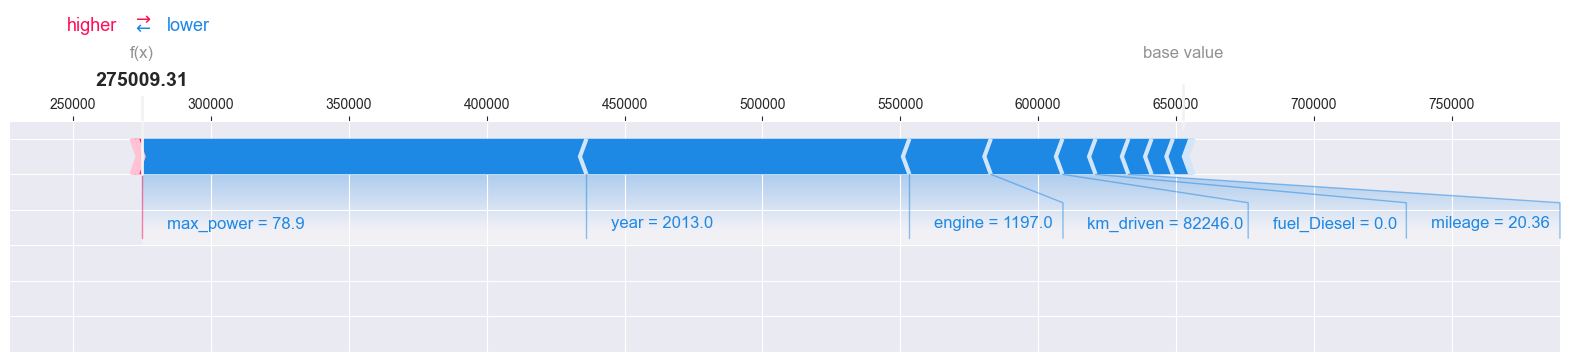

In [57]:
plt.figure(figsize=(10, 6))
plt.title("Importanta globala a caracteristicilor")
shap.plots.bar(explainer(X_test))

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
shap.plots.scatter(explainer(X_test)[:, "max_power"], ax=ax[0])
shap.plots.scatter(explainer(X_test)[:, "year"], ax=ax[1])
plt.tight_layout()
plt.show()

shap.initjs()
shap.plots.force(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:], matplotlib=True)

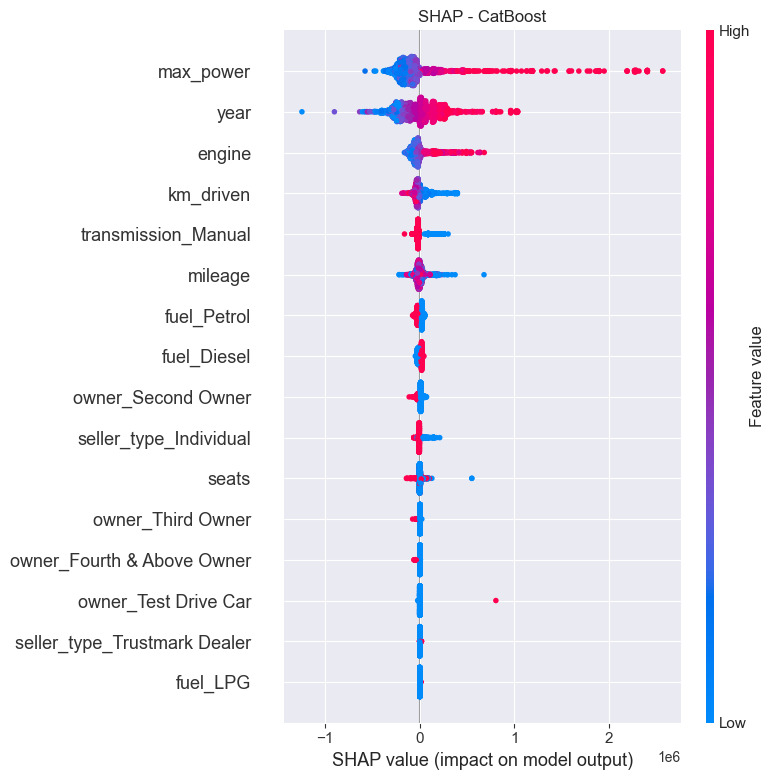

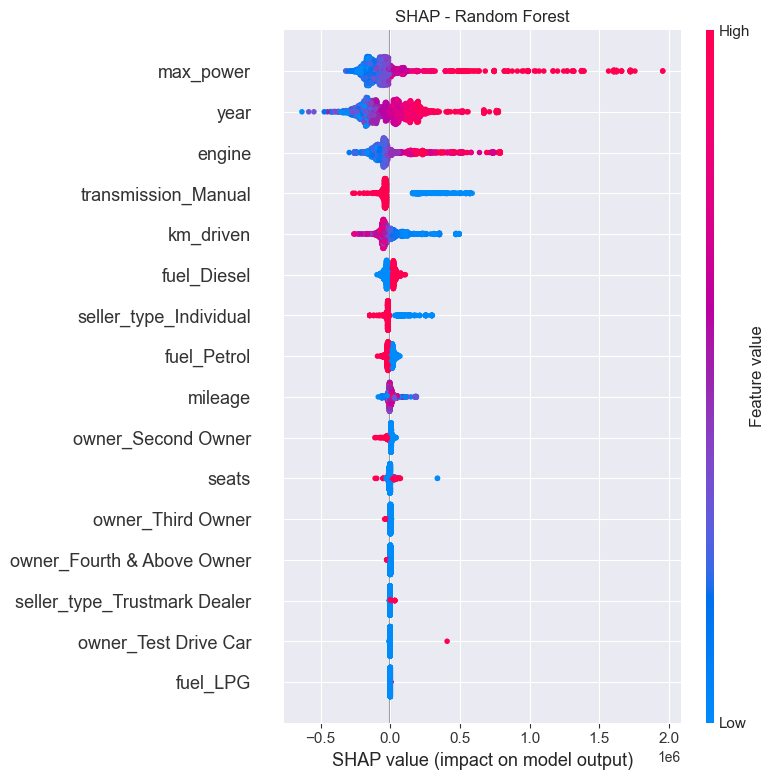

In [58]:
explainer_cat = shap.TreeExplainer(best_cat)
shap_values_cat = explainer_cat.shap_values(X_test)
plt.figure()
plt.title("SHAP - CatBoost")
shap.summary_plot(shap_values_cat, X_test)

explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf.shap_values(X_test)
plt.figure()
plt.title("SHAP - Random Forest")
shap.summary_plot(shap_values_rf, X_test)

In [62]:
joblib.dump(best_xgb, 'model_xgb.pkl')
joblib.dump(best_cat, 'model_cat.pkl')
joblib.dump(best_rf, 'model_rf.pkl')
joblib.dump(best_ebm, 'model_ebm.pkl')
joblib.dump(best_dt, 'model_dt.pkl')

['model_dt.pkl']

In [67]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('shap_xgboost.png', bbox_inches='tight')
plt.close()

plt.figure()
shap.summary_plot(shap_values_cat, X_test, show=False)
plt.savefig('shap_catboost.png', bbox_inches='tight')
plt.close()

plt.figure()
shap.summary_plot(shap_values_rf, X_test, show=False)
plt.savefig('shap_random_forest.png', bbox_inches='tight')
plt.close()

### 6. Explicabilitatea si analiza SHAP
* **Impact global**: Analiza **SHAP Summary Plot** indica faptul ca **max_power** si **year** sunt cei mai importanti factori in predictia pretului.
* **Analiza locala**: Folosind **Waterfall plot**, am demonstrat cum modelul  calculeaza pretul pentru o singura masina. Am observat cum o valoare mare a cailor putere a impins pretul in sus, compensand efectul negativ al vechimii.
